In [1]:
import sys; sys.path.insert(0, "..")
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import poset as P
import pickle
import os
import numpy as np 

In [2]:
import pickle
path = f"..{os.sep}data{os.sep}050_posets.pkl"
with open(path, "rb") as f:
    results = pickle.load(f)

Nei Poset, se un nodo (Nazione A) domina un altro nodo (Nazione B), significa che la Nazione A ha performance uguali o superiori in tutti gli indicatori rispetto alla Nazione B. L'MDS ci dice qual è il numero minimo di "leader" necessari per coprire (superare) tutti gli altri.
ind_2015 (MDS: 1) - Il Leader Assoluto:
L'Estonia (EST_2015) da sola copre l'intero set. Questo è un risultato raro e fortissimo. Significa che l'Estonia, in quell'anno e per quel gruppo di indicatori, aveva un profilo tale da essere uguale o superiore a tutte le altre 15 nazioni. Non c'era nessun paese con una combinazione di valori che potesse "sfidare" l'Estonia su tutta la linea.
ind_2018 (MDS: 2) - La Polarizzazione:
Qui servono due nazioni: Lituania (LTU_2018) e Italia (ITA_2018). Cosa significa? Che questi due paesi offrono due "modelli di eccellenza" diversi e incomparabili tra loro. L'Italia sarà forte in alcuni indicatori dove la Lituania è debole, e viceversa. Tuttavia, mettendole insieme, qualsiasi altro paese europeo del dataset risulta inferiore (o uguale) ad almeno una delle due.
exp_2018 (MDS: 4) ed exp_2015 (MDS: 6) - L'Incomparabilità Diffusa:
Negli scenari "exp" la situazione si complica. Un MDS di 6 nazioni significa che non ci sono leader chiari. I profili dei paesi sono molto "frastagliati": magari la Svezia eccelle nell'indicatore X ma crolla nell'Y, mentre la Lettonia fa l'opposto. C'è molta incomparabilità. Più l'MDS è grande, meno il set di indicatori riesce a creare una gerarchia chiara tra le nazioni.

In [18]:

def get_mds_elements(poset_dict):
    G = nx.DiGraph()
    G.add_nodes_from(poset_dict['elements'])
    G.add_edges_from(poset_dict['dom_certain'])
    C = nx.condensation(G)
    
    massimali = set()
    for n in [node for node, deg in C.in_degree() if deg == 0]:
        massimali.update(C.nodes[n]['members'])
    return massimali

mds_2015 = get_mds_elements(data['ind_2015'])
mds_2018 = get_mds_elements(data['ind_2018'])

clean_2015 = {c.split('_')[0] for c in mds_2015}
clean_2018 = {c.split('_')[0] for c in mds_2018}

stabili = clean_2015.intersection(clean_2018)
usciti = clean_2015 - clean_2018
entrati = clean_2018 - clean_2015

jaccard = len(stabili) / len(clean_2015.union(clean_2018))

print("==================================================")
print("ANALISI DELLA STABILITÀ DELLA LEADERSHIP (MDS)")
print("==================================================")
print(f"Indice di Similarità di Jaccard: {jaccard:.2f} (1.0 = identici, 0.0 = totalmente disgiunti)")
print(f"-> Paesi Leader Stabili (sia 2015 che 2018): {stabili}")
print(f"-> Paesi decaduti dalla Leadership nel 2018: {usciti if usciti else 'Nessuno'}")
print(f"-> Nuovi Paesi Leader entrati nel 2018:     {entrati if entrati else 'Nessuno'}")

ANALISI DELLA STABILITÀ DELLA LEADERSHIP (MDS)
Indice di Similarità di Jaccard: 0.00 (1.0 = identici, 0.0 = totalmente disgiunti)
-> Paesi Leader Stabili (sia 2015 che 2018): set()
-> Paesi decaduti dalla Leadership nel 2018: {'EST'}
-> Nuovi Paesi Leader entrati nel 2018:     {'ITA', 'LTU'}


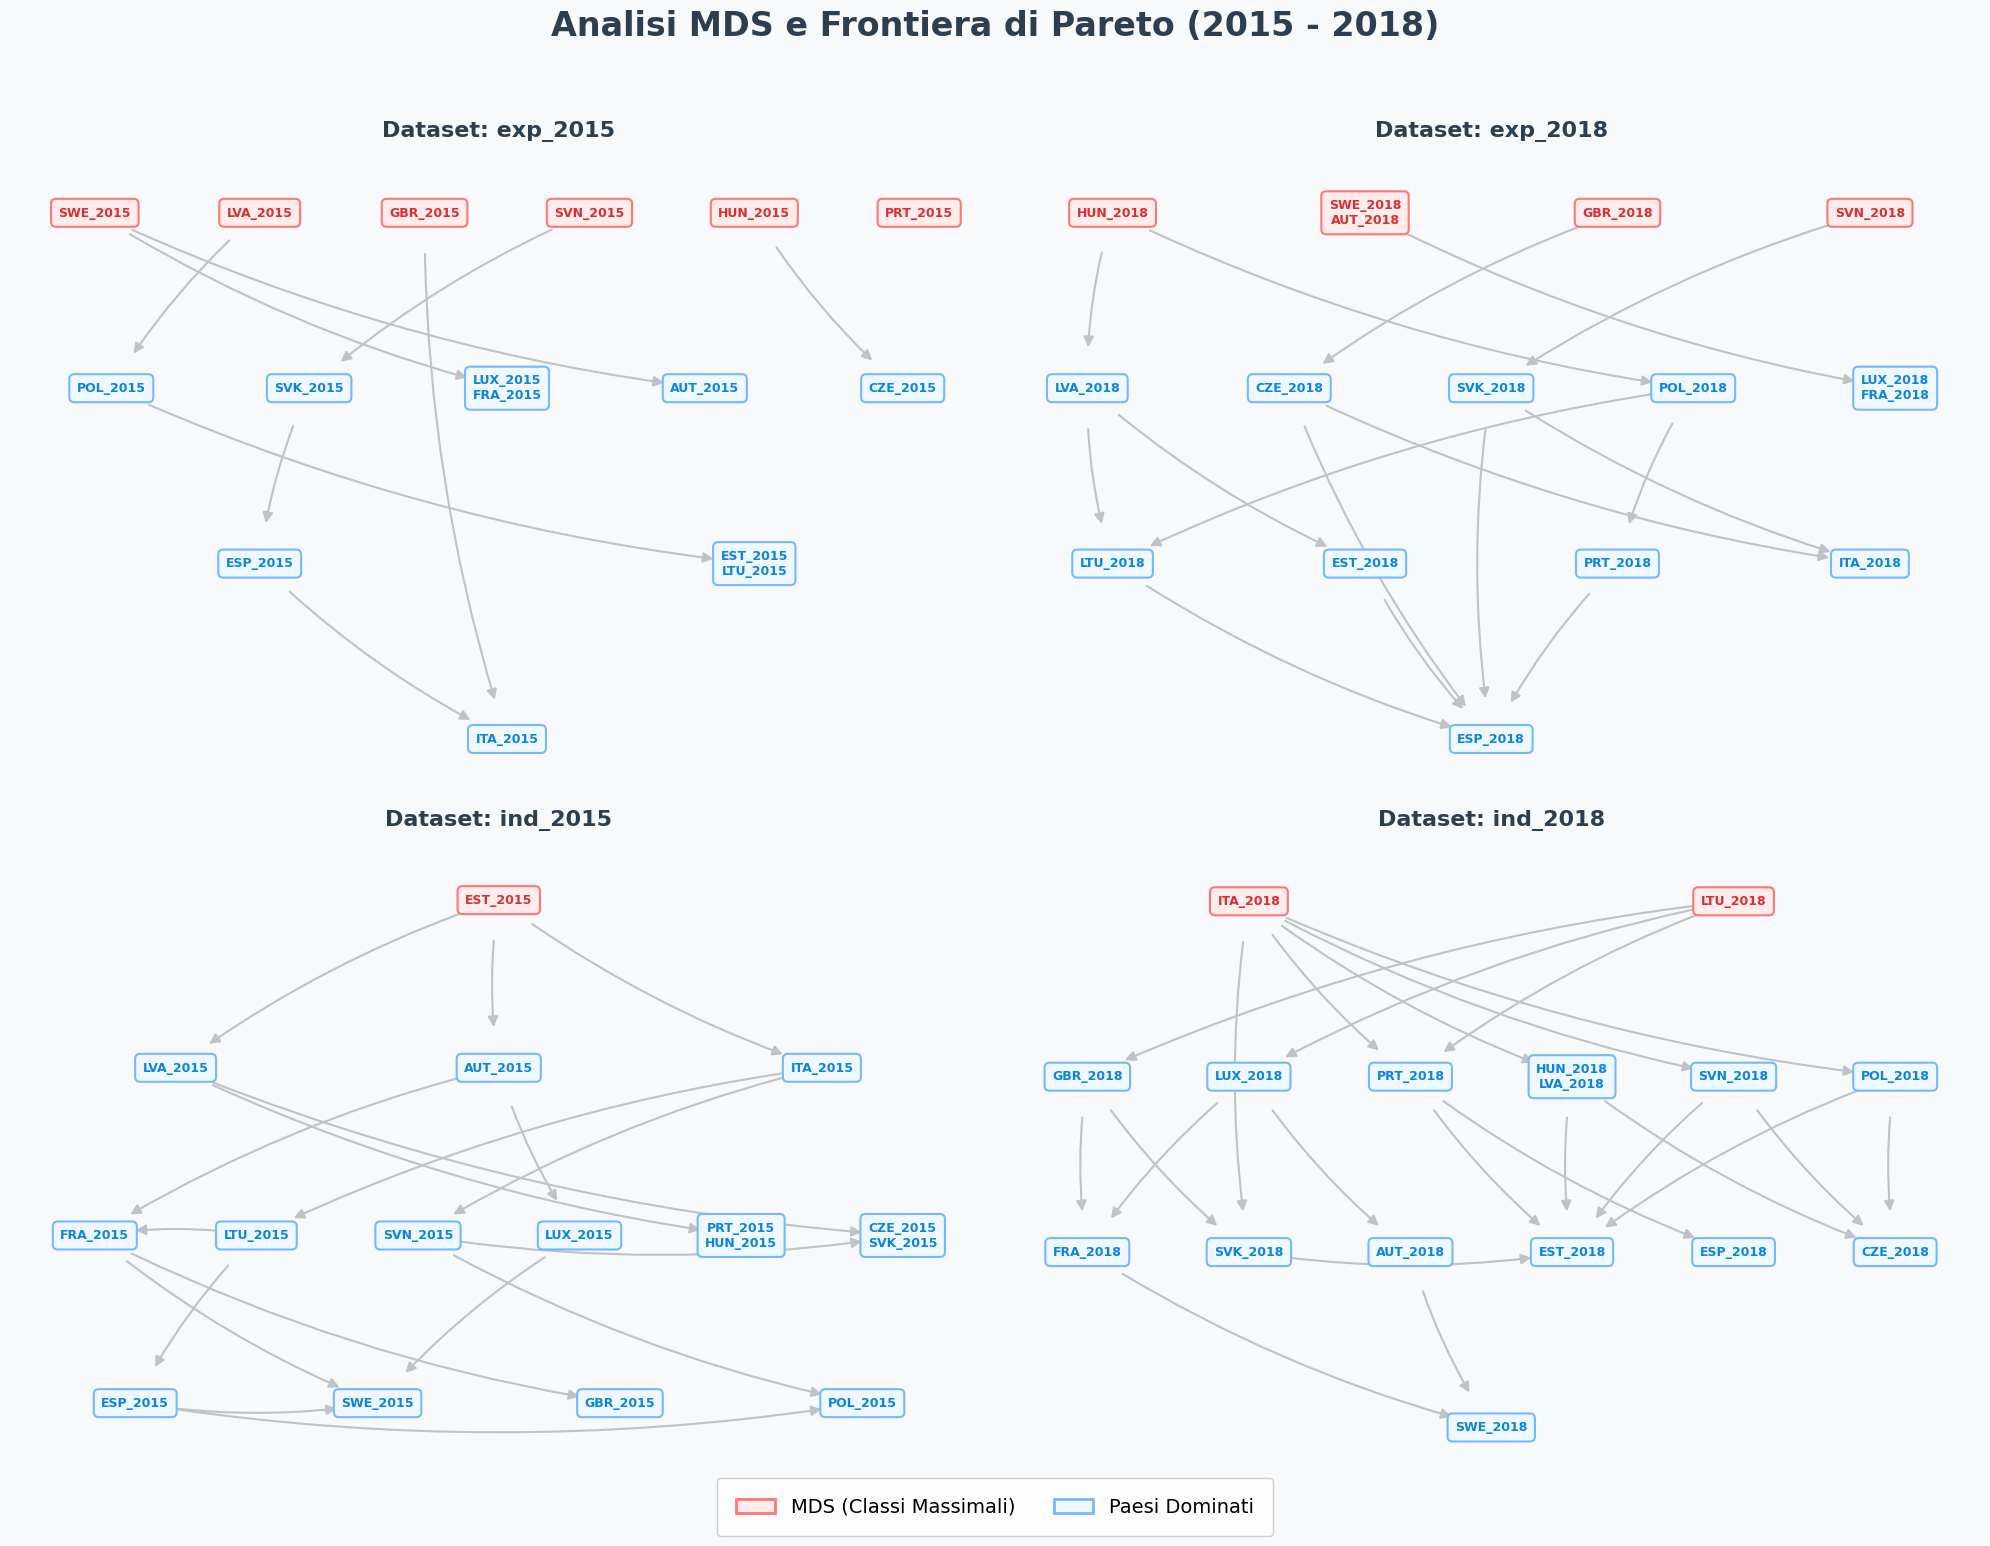

In [20]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_hasse_on_axis(ax, poset_dict, title):
    """
    Disegna un singolo diagramma di Hasse su uno specifico asse (ax) di matplotlib.
    Include la condensazione dei cicli e il calcolo dell'MDS.
    """
    G = nx.DiGraph()
    G.add_nodes_from(poset_dict['elements'])
    G.add_edges_from(poset_dict['dom_certain'])
    C = nx.condensation(G)
    TR_C = nx.transitive_reduction(C)
    
    Hasse_G = nx.DiGraph()
    mapping = {}
    for n in C.nodes():
        members = list(C.nodes[n]['members'])
        label = "\n".join(members)
        mapping[n] = label
        Hasse_G.add_node(label)
        
    for u, v in TR_C.edges():
        Hasse_G.add_edge(mapping[u], mapping[v])
        
    source_supernodes = [n for n, d in C.in_degree() if d == 0]
    massimali_equivalenti = set()
    for n in source_supernodes:
        massimali_equivalenti.update(C.nodes[n]['members'])
        
    layers = {node: 0 for node in Hasse_G.nodes()}
    sources = [n for n in Hasse_G.nodes() if Hasse_G.in_degree(n) == 0]
    
    for src in sources:
        lengths = nx.single_source_shortest_path_length(Hasse_G, src)
        for target, length in lengths.items():
            if length > layers.get(target, -1):
                layers[target] = length
                
    layer_nodes = {}
    for node, layer in layers.items():
        layer_nodes.setdefault(layer, []).append(node)
        
    pos = {}
    max_layer = max(layer_nodes.keys()) if layer_nodes else 0
    for layer, nodes_in_layer in layer_nodes.items():
        y = max_layer - layer  
        n_nodes = len(nodes_in_layer)
        nodes_in_layer = sorted(nodes_in_layer, key=lambda x: -Hasse_G.out_degree(x))
        for i, node in enumerate(nodes_in_layer):
            x = (i - (n_nodes - 1) / 2.0) * (8.0 / max(1, n_nodes))
            pos[node] = (x, y)


    if len(Hasse_G.edges()) > 0:
        nx.draw_networkx_edges(
            Hasse_G, pos, ax=ax,
            edge_color='#BDC3C7', width=1.5,
            arrows=True, arrowsize=15, arrowstyle='-|>',
            node_size=3500, connectionstyle="arc3,rad=0.08"
        )
    
    
    for node in Hasse_G.nodes():
        is_mds = any(max_el in node for max_el in massimali_equivalenti)
        if is_mds:
            bg_color, border_color, text_color = '#FFECEC', '#FF7675', '#D63031'
        else:
            bg_color, border_color, text_color = '#F0F8FF', '#74B9FF', '#0984E3'
            
        ax.text(
            pos[node][0], pos[node][1], node,
            ha='center', va='center', fontsize=9, fontweight='bold', color=text_color,
            bbox=dict(
                boxstyle="round,pad=0.6,rounding_size=0.4",
                facecolor=bg_color, edgecolor=border_color, linewidth=1.5
            )
        )
        
    ax.set_title(title, fontsize=16, fontweight='bold', color='#2C3E50', pad=15)
    ax.axis('off')

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 16), facecolor='#F8F9FA')
fig.suptitle("Analisi MDS e Frontiera di Pareto (2015 - 2018)", 
             fontsize=24, fontweight='bold', color='#2C3E50', y=0.98)

axes = axes.flatten()

keys_to_plot = sorted(list(data.keys()))

for i, key in enumerate(keys_to_plot):
    draw_hasse_on_axis(axes[i], data[key], title=f"Dataset: {key}")

mds_patch = mpatches.Patch(facecolor='#FFECEC', edgecolor='#FF7675', linewidth=2, label='MDS (Classi Massimali)')
dom_patch = mpatches.Patch(facecolor='#F0F8FF', edgecolor='#74B9FF', linewidth=2, label='Paesi Dominati')
fig.legend(handles=[mds_patch, dom_patch], loc='lower center', ncol=2, 
           fontsize=14, frameon=True, facecolor='white', edgecolor='#BDC3C7', borderpad=1, bbox_to_anchor=(0.5, 0.02))

plt.tight_layout(rect=[0, 0.05, 1, 0.95]) 
plt.show()

In [31]:
import numpy as np

def analyze_bottleneck(poset_dict, country_A, country_B):
    """
    Spiega perché il Paese A NON domina il Paese B, 
    individuando su quali indicatori il Paese B è superiore o incomparabile rispetto ad A.
    """
    intervals = poset_dict['intervals']
    cols = poset_dict['indicator_cols']
    
    if country_A not in intervals or country_B not in intervals:
        print("Uno o entrambi i paesi inseriti non sono presenti nel dataset.")
        return

    val_A = intervals[country_A]['hi']
    val_B = intervals[country_B]['lo']
    
    print(f"Analisi: Perché {country_A} NON domina {country_B}?")
    print("-" * 50)
    
    bottleneck_found = False
    for i, col_name in enumerate(cols):
        if val_A[i] < val_B[i]:
            print(f"⚠️ COLLO DI BOTTIGLIA su '{col_name}':")
            print(f"   - {country_A} ha un punteggio massimo di {val_A[i]}")
            print(f"   - {country_B} ha un punteggio minimo garantito di {val_B[i]}")
            bottleneck_found = True
            
    if not bottleneck_found:
        print(f"{country_A} ha valori potenzialmente dominanti su {country_B}, la mancata dominanza totale è dovuta alle sovrapposizioni delle distribuzioni degli intervalli.")

analyze_bottleneck(data['ind_2018'], 'SVN_2018', 'LTU_2018')

Analisi: Perché SVN_2018 NON domina LTU_2018?
--------------------------------------------------
⚠️ COLLO DI BOTTIGLIA su 'material_protection':
   - SVN_2018 ha un punteggio massimo di 1.0
   - LTU_2018 ha un punteggio minimo garantito di 2.0
